# User Behavior Segmentation

Clusters browsing sessions into distinct behavioral segments with KMeans. The labeled `session_segments` dataset feeds the recommendation engine and the dashboard.

Run `mlflow ui` in the project root and open http://localhost:5000 to inspect the logged experiment.

In [1]:
%matplotlib inline

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def _find_project_root() -> Path:
    current = Path.cwd()

    while current != current.parent:
        if (current / "src").is_dir():
            return current

        current = current.parent

    raise RuntimeError("Could not locate the project root (missing src/ directory).")


PROJECT_ROOT = _find_project_root()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import mlflow  # noqa: E402

from src.utils.config_loader import get_paths  # noqa: E402
from src.utils.mlflow_utils import setup_mlflow  # noqa: E402

setup_mlflow()

# Resolve configured paths against the project root so the notebook
# works regardless of the kernel working directory.
raw_paths = get_paths()["paths"]

paths = {
    key: (value if Path(value).is_absolute() else str(PROJECT_ROOT / value))
    for key, value in raw_paths.items()
}

2026-08-12 22:19:39,513 | INFO     | src.utils.mlflow_utils | MLflow tracking URI: mlruns


## Load the Gold Session Features

In [2]:
session_features = pd.read_parquet(paths["session_features_gold"])

print(f"Sessions: {len(session_features):,}")
print(f"Columns:  {len(session_features.columns)}")

session_features.head()

Sessions: 829
Columns:  33


,session_id,session_start,session_end,hour,day_of_week_num,is_weekend,time_of_day,session_hour_span,crosses_midnight,session_duration_seconds,...,top_domain_share,top_category_share,events_per_minute,avg_gap_seconds,median_gap_seconds,max_gap_seconds,category_entropy,domain_entropy,domain_diversity_index,category_switch_count
0,1,2026-05-10 07:57:45.724093+00:00,2026-05-10 08:12:08.458927+00:00,7,6,True,Morning,0.239649,False,862,...,0.578947,0.578947,1.321379,47.929713,4.050482,708.621789,0.981941,0.981941,0.105263,1
1,2,2026-05-10 08:34:14.826913+00:00,2026-05-10 08:57:13.046548+00:00,8,6,True,Morning,0.382839,False,1378,...,0.661765,0.661765,2.960341,20.570442,6.343162,718.089725,0.923120,0.923120,0.029412,2
2,3,2026-05-10 09:37:58.915377+00:00,2026-05-10 09:38:00.676474+00:00,9,6,True,Morning,0.000489,False,1,...,0.500000,0.500000,68.139347,1.761097,1.761097,1.761097,1.000000,1.000000,1.000000,1
3,4,2026-05-10 10:30:32.549173+00:00,2026-05-10 10:38:12.898864+00:00,10,6,True,Morning,0.127875,False,460,...,0.615385,0.615385,3.388728,18.413988,6.597838,142.365179,1.141620,1.141620,0.115385,2
4,5,2026-05-10 10:54:24.152772+00:00,2026-05-10 12:17:26.390661+00:00,10,6,True,Morning,1.383955,False,4982,...,0.788235,0.788235,1.023636,59.312356,5.134148,861.995084,0.744842,0.744842,0.023529,6


## Run the Clustering Pipeline

In [3]:
from src.clustering.pipeline import ClusteringPipeline

pipeline = ClusteringPipeline(
    input_path=paths["session_features_gold"],
    output_path=paths["session_segments"],
    report_dir=paths["clustering_reports"],
)

result = pipeline.run()

analysis = result["analysis"]
optimal_k = result["optimal_k"]

print(f"Optimal number of segments: {optimal_k}")
print(f"Segmented sessions: {len(result['segments']):,}")

2026-08-12 22:19:41,027 | INFO     | src.clustering.pipeline | Starting clustering pipeline.


2026-08-12 22:19:41,060 | INFO     | src.clustering.preprocessor | Clustering preprocessor fitted | features=26 | pca_components=10


2026-08-12 22:19:42,676 | INFO     | src.clustering.segmenter | Cluster sweep completed | range=2..10 | optimal_k=2


2026-08-12 22:19:42,798 | INFO     | src.clustering.segmenter | KMeans segmentation fitted | k=2 | inertia=16122.35


2026-08-12 22:19:42,803 | INFO     | src.clustering.pipeline | Segments assigned | sessions=829 | segments=2


...

2026/08/12 22:20:12 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!


2026/08/12 22:20:23 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


2026-08-12 22:20:23,483 | INFO     | src.clustering.pipeline | MLflow run logged | run_id=ba2718e9cd9740e38d41bd0ee1fba4ce


2026-08-12 22:20:23,485 | INFO     | src.clustering.pipeline | Clustering pipeline completed.


Optimal number of segments: 2
Segmented sessions: 829


In [4]:
metrics = pd.DataFrame(
    {
        "k": analysis.k_values,
        "inertia": analysis.inertia,
        "silhouette": analysis.silhouette,
        "davies_bouldin": analysis.davies_bouldin,
        "calinski_harabasz": analysis.calinski_harabasz,
    }
).set_index("k")

metrics

,inertia,silhouette,davies_bouldin,calinski_harabasz
k,,,,
2,16122.353987,0.279813,1.608689,236.093827
3,13515.594805,0.219896,1.484677,220.299912
4,12154.813992,0.217187,1.452989,193.898578
5,11057.967308,0.215580,1.335157,180.088137
6,10174.980107,0.200357,1.392405,170.666995
7,9243.802016,0.204724,1.377006,170.159867
8,8708.382363,0.224473,1.310034,161.841491
9,8280.315292,0.217710,1.306163,154.049712
10,7884.133823,0.219872,1.280688,148.211439


### Elbow & Silhouette

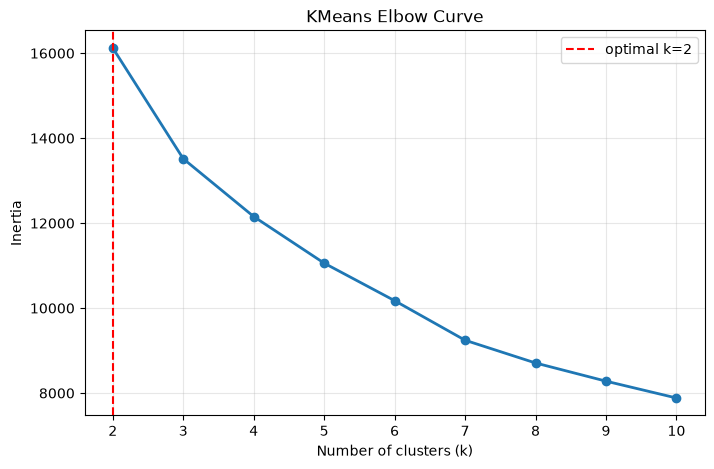

In [5]:
fig, axis = plt.subplots(figsize=(8, 5))

axis.plot(metrics.index, metrics["inertia"], marker="o", linewidth=2)
axis.axvline(optimal_k, color="red", linestyle="--", label=f"optimal k={optimal_k}")
axis.set_title("KMeans Elbow Curve")
axis.set_xlabel("Number of clusters (k)")
axis.set_ylabel("Inertia")
axis.grid(True, alpha=0.3)
axis.legend()

plt.show()

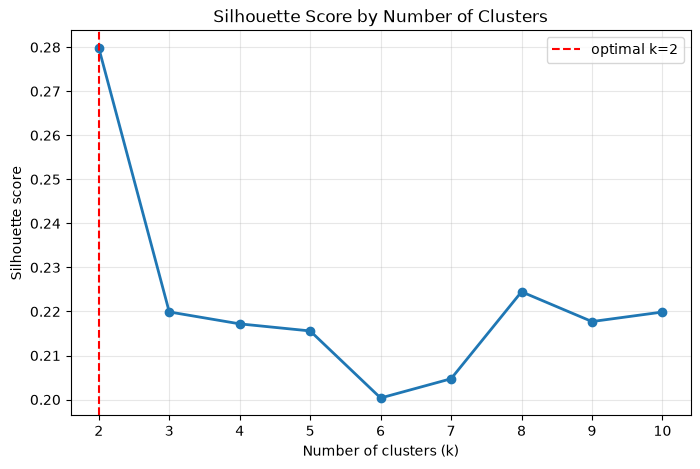

In [6]:
fig, axis = plt.subplots(figsize=(8, 5))

axis.plot(metrics.index, metrics["silhouette"], marker="o", linewidth=2)
axis.axvline(optimal_k, color="red", linestyle="--", label=f"optimal k={optimal_k}")
axis.set_title("Silhouette Score by Number of Clusters")
axis.set_xlabel("Number of clusters (k)")
axis.set_ylabel("Silhouette score")
axis.grid(True, alpha=0.3)
axis.legend()

plt.show()

## Segment Profiles

In [7]:
profile = result["profile"]

print(f"Segments: {len(profile)}")

profile[
    [
        "segment_id",
        "session_count",
        "share_pct",
        "dominant_category",
        "avg_usage_percent",
        "avg_used_mb",
        "session_duration_seconds",
        "event_count",
    ]
]

Segments: 2


,segment_id,session_count,share_pct,dominant_category,avg_usage_percent,avg_used_mb,session_duration_seconds,event_count
0,0.0,232,27.99,Search/Reference,43.1348,3533.6028,2266.9310,80.1724
1,1.0,597,72.01,Search/Reference,41.5053,3400.1190,246.6332,12.2563


In [8]:
from src.clustering.profiler import SegmentProfiler

importances = SegmentProfiler.dominant_feature_importances(profile, top_n=4)

for segment, ranked in sorted(importances.items()):
    print(f"Segment {segment}:")
    for feature, deviation in ranked:
        print(f"  {feature:30s} {deviation:+.2f}")

Segment 0:
  session_duration_seconds       +1010.15
  total_visit_count              +687.27
  max_used_mb                    +225.25
  max_gap_seconds                +188.24
Segment 1:
  session_duration_seconds       -1010.15
  total_visit_count              -687.27
  max_used_mb                    -225.25
  max_gap_seconds                -188.24


### Segment Visualization (PCA)

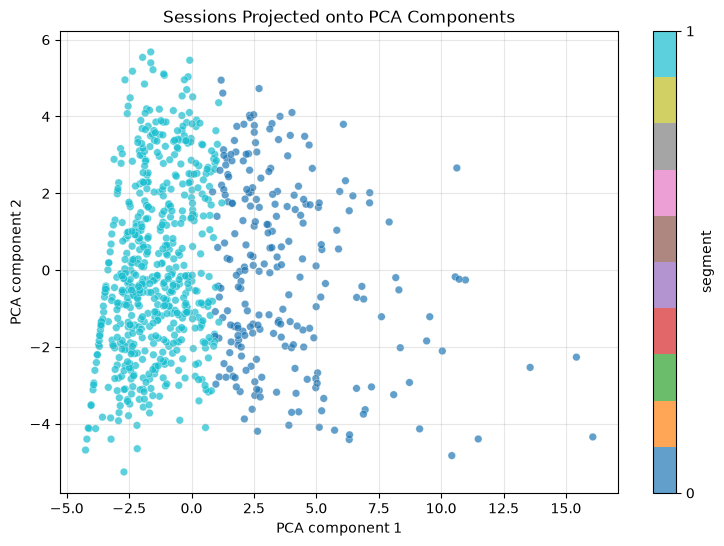

In [9]:
matrix = pipeline.preprocessor.transform(session_features)
pca_coords = pipeline.preprocessor.project(matrix)

fig, axis = plt.subplots(figsize=(9, 6))

scatter = axis.scatter(
    pca_coords[:, 0],
    pca_coords[:, 1],
    c=result["result"].labels,
    cmap="tab10",
    s=30,
    alpha=0.7,
    edgecolors="white",
    linewidths=0.3,
)

axis.set_title("Sessions Projected onto PCA Components")
axis.set_xlabel("PCA component 1")
axis.set_ylabel("PCA component 2")
axis.grid(True, alpha=0.3)
fig.colorbar(scatter, ax=axis, label="segment", ticks=range(optimal_k))

plt.show()

## Labeled Segment Dataset

In [10]:
segments = result["segments"]

segments[["session_id", "segment_id", "distance_to_centroid"]].head(10)

,session_id,segment_id,distance_to_centroid
0,1,1,4.417341
1,2,0,4.306324
2,3,1,6.599628
3,4,1,3.655583
4,5,0,6.255291
5,6,0,3.783856
6,7,1,3.301109
7,8,0,5.361753
8,9,1,4.166964
9,10,1,3.248343


## MLflow Experiment

In [11]:
from src.utils.mlflow_utils import get_experiment_id, get_experiment_name

experiment_id = get_experiment_id(get_experiment_name("clustering"))

experiment = mlflow.get_experiment(experiment_id)

print(f"Experiment: {experiment.name}")
print(f"Experiment ID: {experiment.experiment_id}")

runs = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    output_format="list",
)

run = runs[0]

print(f"Run ID: {run.info.run_id}")
print(f"k = {run.data.params.get('k')}")
print(f"silhouette = {run.data.metrics.get('silhouette_score'):.4f}")
print()

print("Logged artifacts:")
print(run.info.artifact_uri)

Experiment: browser-behavior-clustering
Experiment ID: 415300990315419043
Run ID: ba2718e9cd9740e38d41bd0ee1fba4ce
k = 2
silhouette = 0.2798

Logged artifacts:
/home/abishek/Projects/intelligent-browser-behaviour-analytics-platform/notebooks/mlruns/415300990315419043/ba2718e9cd9740e38d41bd0ee1fba4ce/artifacts
